<a href="https://colab.research.google.com/github/ahmadbinjaffar/ahmadbinjaffar/blob/main/Churn_Prediction_SaaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# PHASE 1 — LOAD & EXPLORE DATA
# ============================================

# Step 1: Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Step 3: Basic exploration
print("Shape of data (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Shape of data (rows, columns): (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  Tec

In [4]:
# Check exact number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Rows: 7043
Columns: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
# ============================================
# PHASE 2 — DATA CLEANING
# ============================================

# Step 1: Remove customerID (useless for prediction)
df = df.drop('customerID', axis=1)

In [6]:
# Step 2: Fix TotalCharges column (it's text, should be number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# Step 3: Check missing values after fix
print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [8]:
# Step 4: Drop the few missing rows
df = df.dropna()
print("\nNew shape after cleaning:", df.shape)


New shape after cleaning: (7032, 20)


In [9]:
# Step 5: Convert Churn to 0 and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("\nChurn after converting:")
print(df['Churn'].value_counts())


Churn after converting:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [10]:
# Step 6: Convert all Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [11]:
# Step 7: One-Hot Encoding for remaining text columns
df = pd.get_dummies(df, drop_first=True)
print("\nFinal shape after encoding:", df.shape)
print("\nCleaning Complete! ✅")


Final shape after encoding: (7032, 31)

Cleaning Complete! ✅


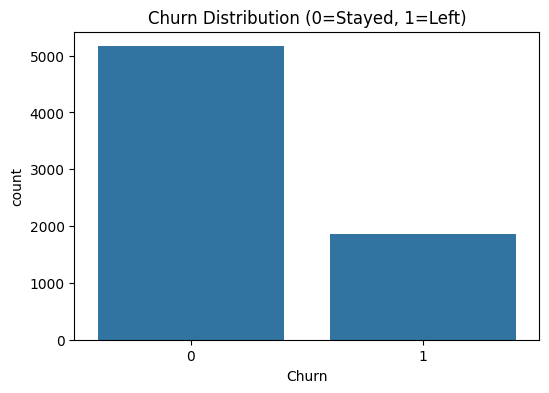

In [12]:
# ============================================
# PHASE 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# Step 1: Churn Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (0=Stayed, 1=Left)')
plt.show()

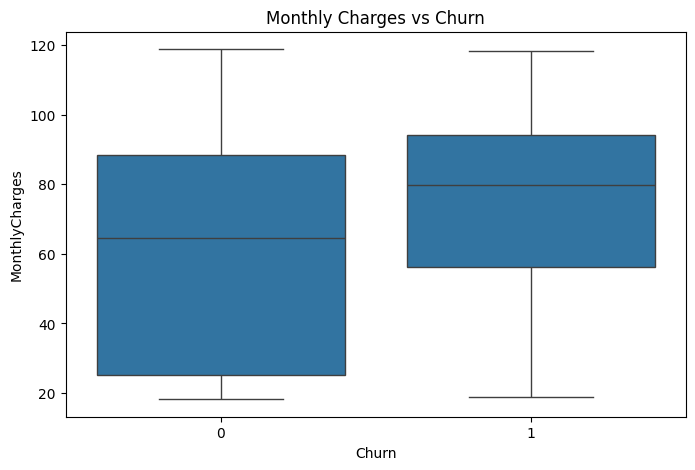

In [13]:
# Step 2: Churn vs Monthly Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


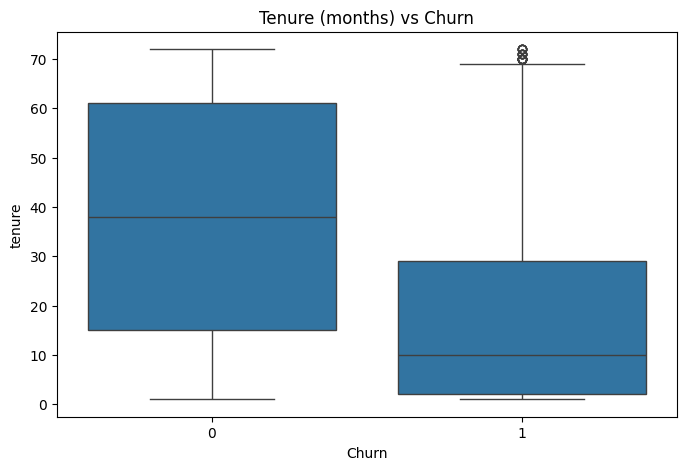

In [14]:

# Step 3: Churn vs Tenure
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure (months) vs Churn')
plt.show()

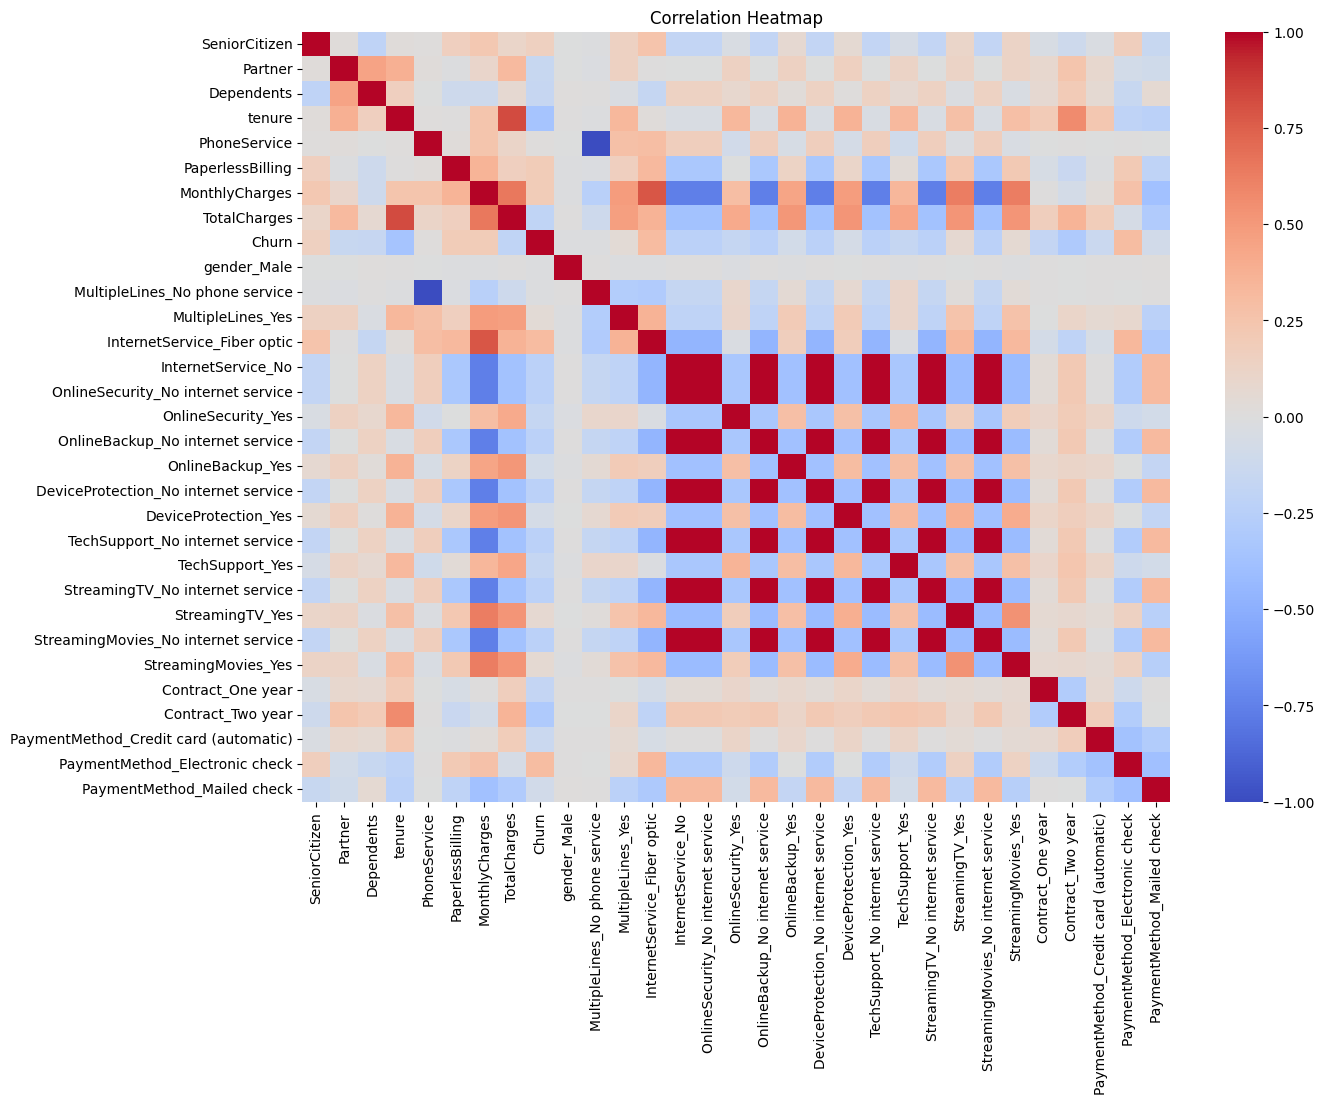

In [15]:
# Step 4: Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [16]:
# Step 5: Print key insights
print("Average Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())
print("\nAverage Tenure (months):")
print(df.groupby('Churn')['tenure'].mean())

Average Monthly Charges:
Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Average Tenure (months):
Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64


In [17]:
# ============================================
# PHASE 4 — BUILDING ML MODELS
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE


In [18]:
# Step 1: Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [19]:
# Step 2: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5625, 30)
Testing size: (1407, 30)


In [20]:
# Step 3: Apply SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64


In [21]:
# Step 4: Scale the features
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

print("\nData Ready for Modeling! ✅")


Data Ready for Modeling! ✅


In [22]:
# ============================================
# PHASE 4 — TRAINING ALL 3 MODELS
# ============================================

# ---- MODEL 1: Logistic Regression ----
print("=" * 40)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 40)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print(classification_report(y_test, lr_pred))
print("ROC-AUC Score:", round(lr_auc, 4))

MODEL 1: LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.64      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407

ROC-AUC Score: 0.8106


In [23]:
# ---- MODEL 2: Decision Tree ----
print("=" * 40)
print("MODEL 2: DECISION TREE")
print("=" * 40)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)
dt_pred = dt.predict(X_test)
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
print(classification_report(y_test, dt_pred))
print("ROC-AUC Score:", round(dt_auc, 4))

MODEL 2: DECISION TREE
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1033
           1       0.48      0.55      0.51       374

    accuracy                           0.72      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.72      0.73      1407

ROC-AUC Score: 0.6679


In [24]:
# ---- MODEL 3: Random Forest ----
print("=" * 40)
print("MODEL 3: RANDOM FOREST")
print("=" * 40)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(classification_report(y_test, rf_pred))
print("ROC-AUC Score:", round(rf_auc, 4))

MODEL 3: RANDOM FOREST
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.56      0.57      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC Score: 0.8058


MODEL COMPARISON TABLE
                 Model  Accuracy  ROC-AUC
0  Logistic Regression    0.7626   0.8106
1        Decision Tree    0.7228   0.6679
2        Random Forest    0.7655   0.8058

K-FOLD CROSS VALIDATION (k=5)
Logistic Regression CV Score: 0.8977
Decision Tree CV Score:       0.7899
Random Forest CV Score:       0.9249


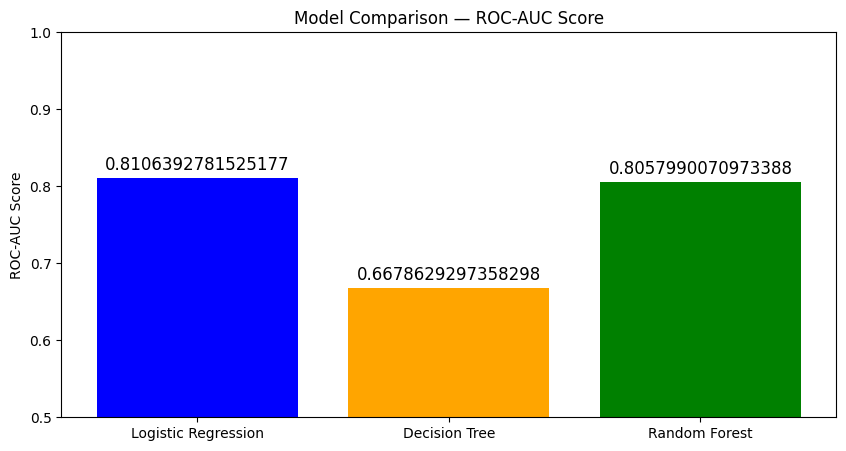

In [25]:
# ============================================
# PHASE 5 — COMPARE ALL 3 MODELS
# ============================================

from sklearn.model_selection import cross_val_score

# ---- Comparison Table ----
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        round(lr.score(X_test, y_test), 4),
        round(dt.score(X_test, y_test), 4),
        round(rf.score(X_test, y_test), 4)
    ],
    'ROC-AUC': [
        round(lr_auc, 4),
        round(dt_auc, 4),
        round(rf_auc, 4)
    ]
}

results_df = pd.DataFrame(results)
print("=" * 50)
print("MODEL COMPARISON TABLE")
print("=" * 50)
print(results_df)

# ---- K-Fold Cross Validation ----
print("\n" + "=" * 50)
print("K-FOLD CROSS VALIDATION (k=5)")
print("=" * 50)

lr_cv = cross_val_score(lr, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')
dt_cv = cross_val_score(dt, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')

print(f"Logistic Regression CV Score: {round(lr_cv.mean(), 4)}")
print(f"Decision Tree CV Score:       {round(dt_cv.mean(), 4)}")
print(f"Random Forest CV Score:       {round(rf_cv.mean(), 4)}")

# ---- Visual Comparison ----
plt.figure(figsize=(10, 5))
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
auc_scores = [lr_auc, dt_auc, rf_auc]
colors = ['blue', 'orange', 'green']
bars = plt.bar(models, auc_scores, color=colors)
plt.title('Model Comparison — ROC-AUC Score')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.5, 1.0)
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             str(score), ha='center', fontsize=12)
plt.show()

TOP 10 MOST IMPORTANT FEATURES:
                           Feature  Importance
7                     TotalCharges    0.166023
3                           tenure    0.147336
6                   MonthlyCharges    0.136725
28  PaymentMethod_Electronic check    0.105311
11     InternetService_Fiber optic    0.057089
2                       Dependents    0.033447
26               Contract_Two year    0.032023
1                          Partner    0.031319
8                      gender_Male    0.024059
10               MultipleLines_Yes    0.022592


/tmp/ipykernel_2465/4282740084.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


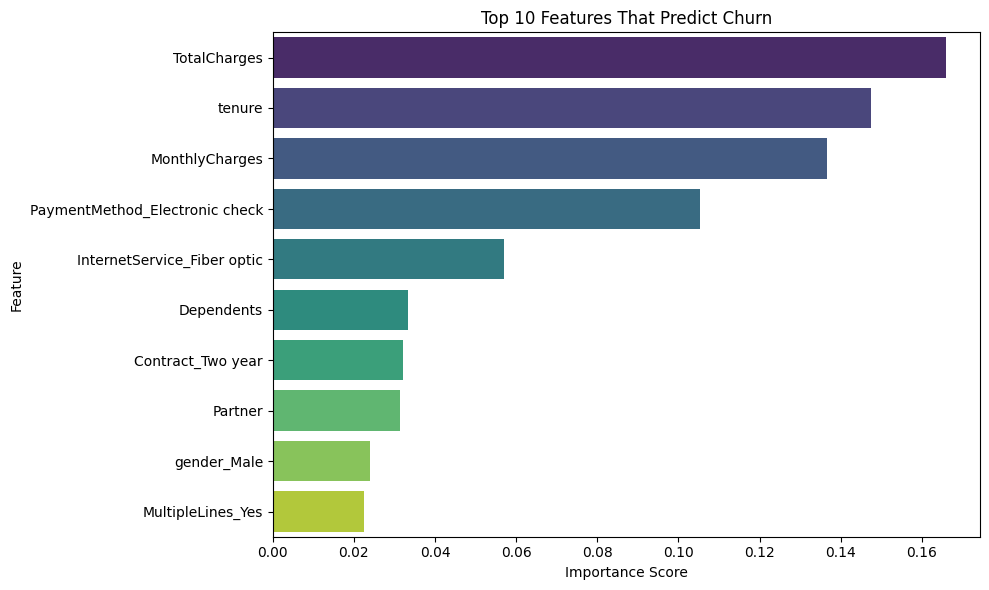

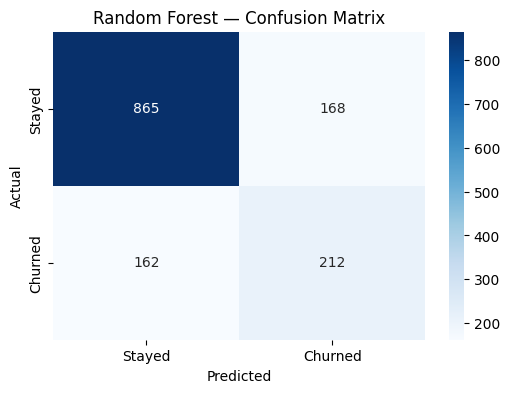


FINAL PROJECT SUMMARY
Total Customers Analyzed: 7032
Features Used: 30
Best Model: Random Forest
Best ROC-AUC Score: 0.8058
Best CV Score: 0.9249

Project Complete! ✅🎉


In [26]:
# ============================================
# PHASE 6 — FEATURE IMPORTANCE & FINAL PLOTS
# ============================================

# ---- Feature Importance from Random Forest ----
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("TOP 10 MOST IMPORTANT FEATURES:")
print(importance_df)

# ---- Plot Feature Importance ----
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=importance_df, palette='viridis')
plt.title('Top 10 Features That Predict Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix for Random Forest ----
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ---- Final Summary ----
print("\n" + "=" * 50)
print("FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"Total Customers Analyzed: {len(df)}")
print(f"Features Used: {X.shape[1]}")
print(f"Best Model: Random Forest")
print(f"Best ROC-AUC Score: {round(rf_auc, 4)}")
print(f"Best CV Score: {round(rf_cv.mean(), 4)}")
print("\nProject Complete! ✅🎉")